## The objective is to understand the fluctuations in the Consumer Price Indexes of some of the most popular grocery store prices.

# Imports

In [ ]:
!pip install numpy==1.26.4

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Import libraries for ARIMA
from statsmodels.tsa.arima.model import ARIMA
!pip install pmdarima
from pmdarima.arima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Import libraries for clustering and PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from ipywidgets import interact, IntSlider

# Remove FutureWarnings from outputs
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# Import to mount Google Drive for data storage and access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# BLS Data Preprocessing/Standardization

## Series Concatenation

The following is a mapping of Series ID to Series Name. This will be used to assign manageable names to each series in a singular dataframe.


Series ID - Series Name

APU0000704111 - Bacon, sliced, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000702111 - Bread, white, pan, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000FF1101- Chicken breast, boneless, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000717311 - Coffee, 100%, ground roast, all sizes, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000708111 - Eggs, grade A, large, per doz. in U.S. city average, average price, not seasonally adjusted

APU0000703112 - Ground beef, 100% beef, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000712112 - Potatoes, white, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000701312 - Rice, white, long grain, uncooked, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000703613 - Steak, sirloin, USDA Choice, boneless, per lb. (453.6 gm) in U.S. city average, average price, not seasonally adjusted

APU0000709112 - Milk, fresh, whole, fortified, per gal. (3.8 lit) in U.S. city average, average price, not seasonally adjusted

CUUR0000SAF11 - Food at home in U.S. city average, all urban consumers, not seasonally adjusted

---









In [ ]:
# Define a dictionary to map series ID to a meaningful name
series_dict = {
    'APU0000704111': 'Bacon, sliced, per lb.',
    'APU0000702111': 'Bread, white, pan, per lb.',
    'APU0000FF1101': 'Chicken breast, boneless, per lb.',
    'APU0000717311': 'Coffee, 100%, ground roast, all sizes, per lb.',
    'APU0000708111': 'Eggs, grade A, large, per doz.',
    'APU0000703112': 'Ground beef, 100% beef, per lb.',
    'APU0000712112': 'Potatoes, white, per lb.',
    'APU0000701312': 'Rice, white, long grain, uncooked, per lb.',
    'APU0000703613': 'Steak, sirloin, USDA Choice, boneless, per lb.',
    'APU0000709112': 'Milk, fresh, whole, fortified, per gal.',
    'CUUR0000SAF11': 'Food at home in U.S. city'
 }

In [ ]:
# Use glob to retrieve all csv files downloaded from the Bureau of Labor Statistics
files = glob.glob('/content/drive/MyDrive/Data Mining/bls datasets/*.csv')

# Read each file and append to a dataframe
series = []
for file in files:
  df = pd.read_csv(file)
  series.append(df)

# Concatenate the data into a single dataframe
df = pd.concat(series, ignore_index=True)

print(df.head())

       Series ID  Year Period     Label  Value
0  APU0000704111  2015    M01  2015 Jan  5.589
1  APU0000704111  2015    M02  2015 Feb  5.472
2  APU0000704111  2015    M03  2015 Mar  5.367
3  APU0000704111  2015    M04  2015 Apr  5.211
4  APU0000704111  2015    M05  2015 May  4.940


## Data Standardization

Standardize all dates to a datetime format for time series analysis.

In [ ]:
# Change label to a datetime
df['Date'] = pd.to_datetime(df['Label'])
# Map series ID to a manageable name
df['Name'] = df['Series ID'].map(series_dict)
df.drop(columns=['Series ID','Period', 'Label', 'Year'], inplace=True)
df.head()

<ipython-input-9-bc3f93fc6b1d>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Label'])


,Value,Date,Name
0,5.589,2015-01-01,"Bacon, sliced, per lb."
1,5.472,2015-02-01,"Bacon, sliced, per lb."
2,5.367,2015-03-01,"Bacon, sliced, per lb."
3,5.211,2015-04-01,"Bacon, sliced, per lb."
4,4.940,2015-05-01,"Bacon, sliced, per lb."


Pivot all data to a single dataframe and impute missing values.

In [ ]:
# Pivot the data on a datetime index
grocery_price_df = df.pivot_table(index='Date', columns='Name', values='Value')
grocery_price_df

# Interpolate to impute missing values
grocery_price_df.interpolate(method='linear', inplace=True)

# Remove multiindexing
grocery_price_df.columns.name = None

# Sort columns based on series_dict - used to have the "Food at Home" column at the end
ordered_cols = list(series_dict.values())
grocery_price_df = grocery_price_df[ordered_cols]
grocery_price_df

,"Bacon, sliced, per lb.","Bread, white, pan, per lb.","Chicken breast, boneless, per lb.","Coffee, 100%, ground roast, all sizes, per lb.","Eggs, grade A, large, per doz.","Ground beef, 100% beef, per lb.","Potatoes, white, per lb.","Rice, white, long grain, uncooked, per lb.","Steak, sirloin, USDA Choice, boneless, per lb.","Milk, fresh, whole, fortified, per gal.",Food at home in U.S. city
Date,,,,,,,,,,,
2015-01-01,5.589,1.479,3.438,4.738,2.113,4.235,0.668,0.692,8.080,3.758,243.123
2015-02-01,5.472,1.435,3.511,4.910,2.088,4.238,0.646,0.689,8.194,3.496,242.906
2015-03-01,5.367,1.440,3.522,4.827,2.133,4.200,0.639,0.670,8.372,3.463,241.588
2015-04-01,5.211,1.454,3.504,4.990,2.065,4.231,0.645,0.670,8.329,3.397,241.305
2015-05-01,4.940,1.463,3.408,4.715,1.962,4.136,0.646,0.676,8.816,3.387,241.019
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,6.785,1.951,3.952,6.311,3.204,5.577,1.006,1.085,11.540,4.044,306.402
2024-09-01,6.955,1.976,3.974,6.470,3.821,5.670,1.009,1.078,11.787,4.021,307.767
2024-10-01,6.869,1.937,4.037,6.644,3.370,5.588,0.998,1.056,11.497,4.041,308.200


# Preliminary Data Visualization

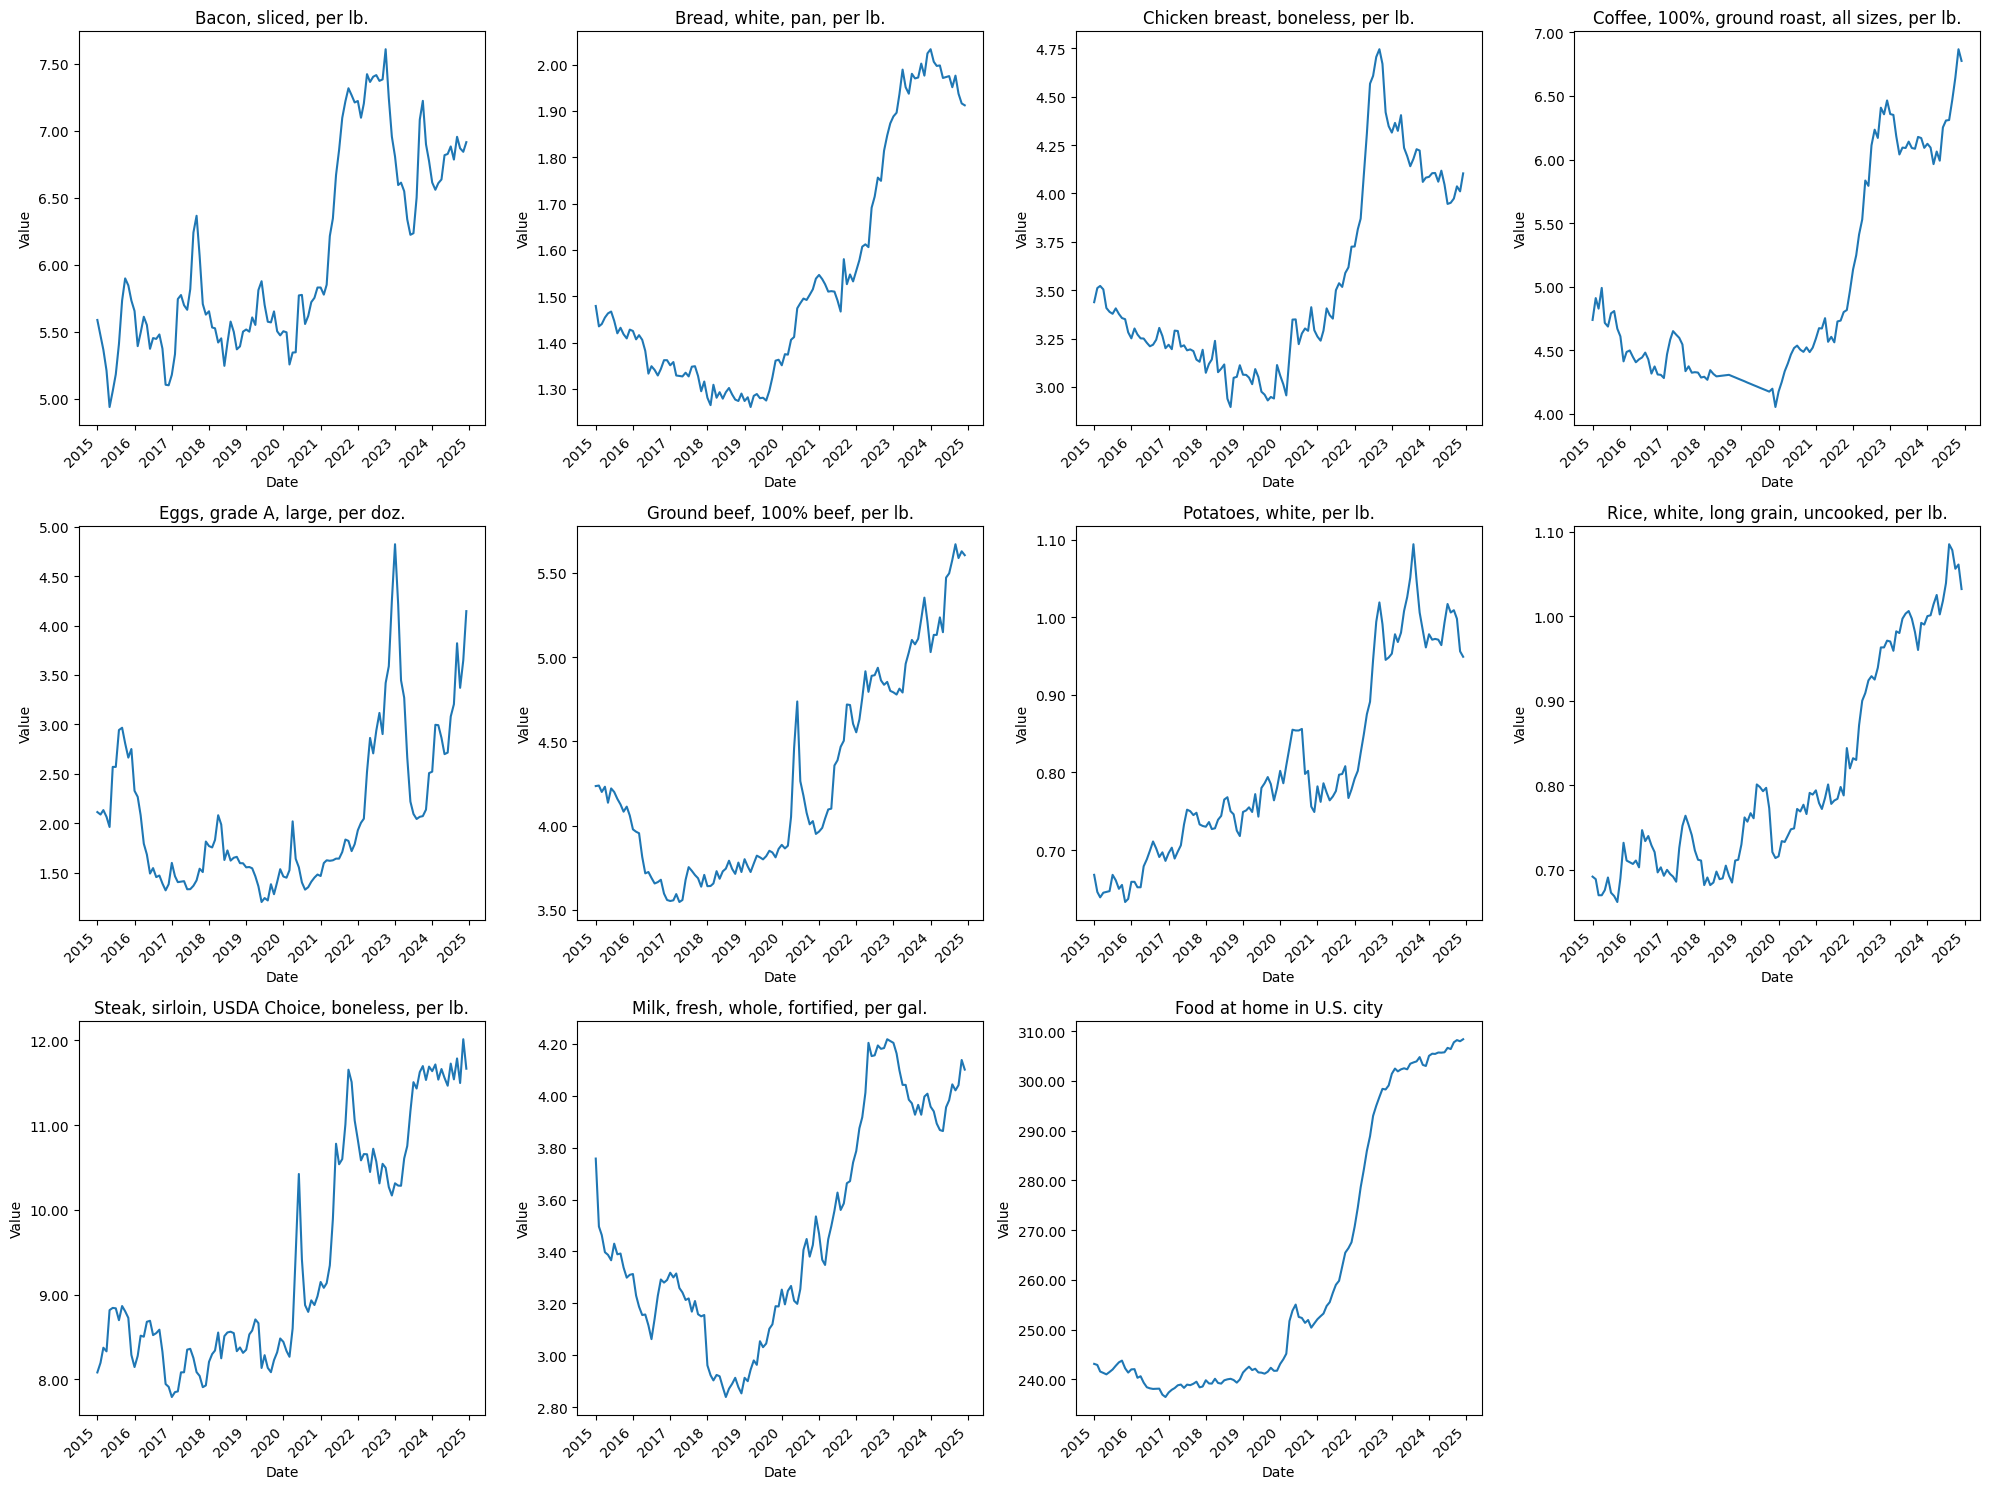

In [ ]:
# Create subplots with 3 rows and 4 columns
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # Adjust figsize as needed

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through columns (excluding 'Date' as it is the index) and plot each in a subplot
for i, col in enumerate(grocery_price_df.columns):
    axes[i].plot(grocery_price_df.index, grocery_price_df[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')
    # Format y axis ticks to 2 decimal places
    axes[i].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.2f}'))
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


By having a preliminary look on each series, we notice that there is a trend in each product. For all products, a drastic increase in prices occurred at some point in or after 2020. This could be attributed to supply and demand created by the COVID Pandemic, although more analysis is needed to determine a cause-effect relationship.

# ARIMA Time Series Forecasting

## Autocorrelation Function (ACF) & Partial Autocorrelation Function (PACF)

### Autocorrelation Function (ACF) Plot

Plot an Autocorrelation Function (ACF) plot.

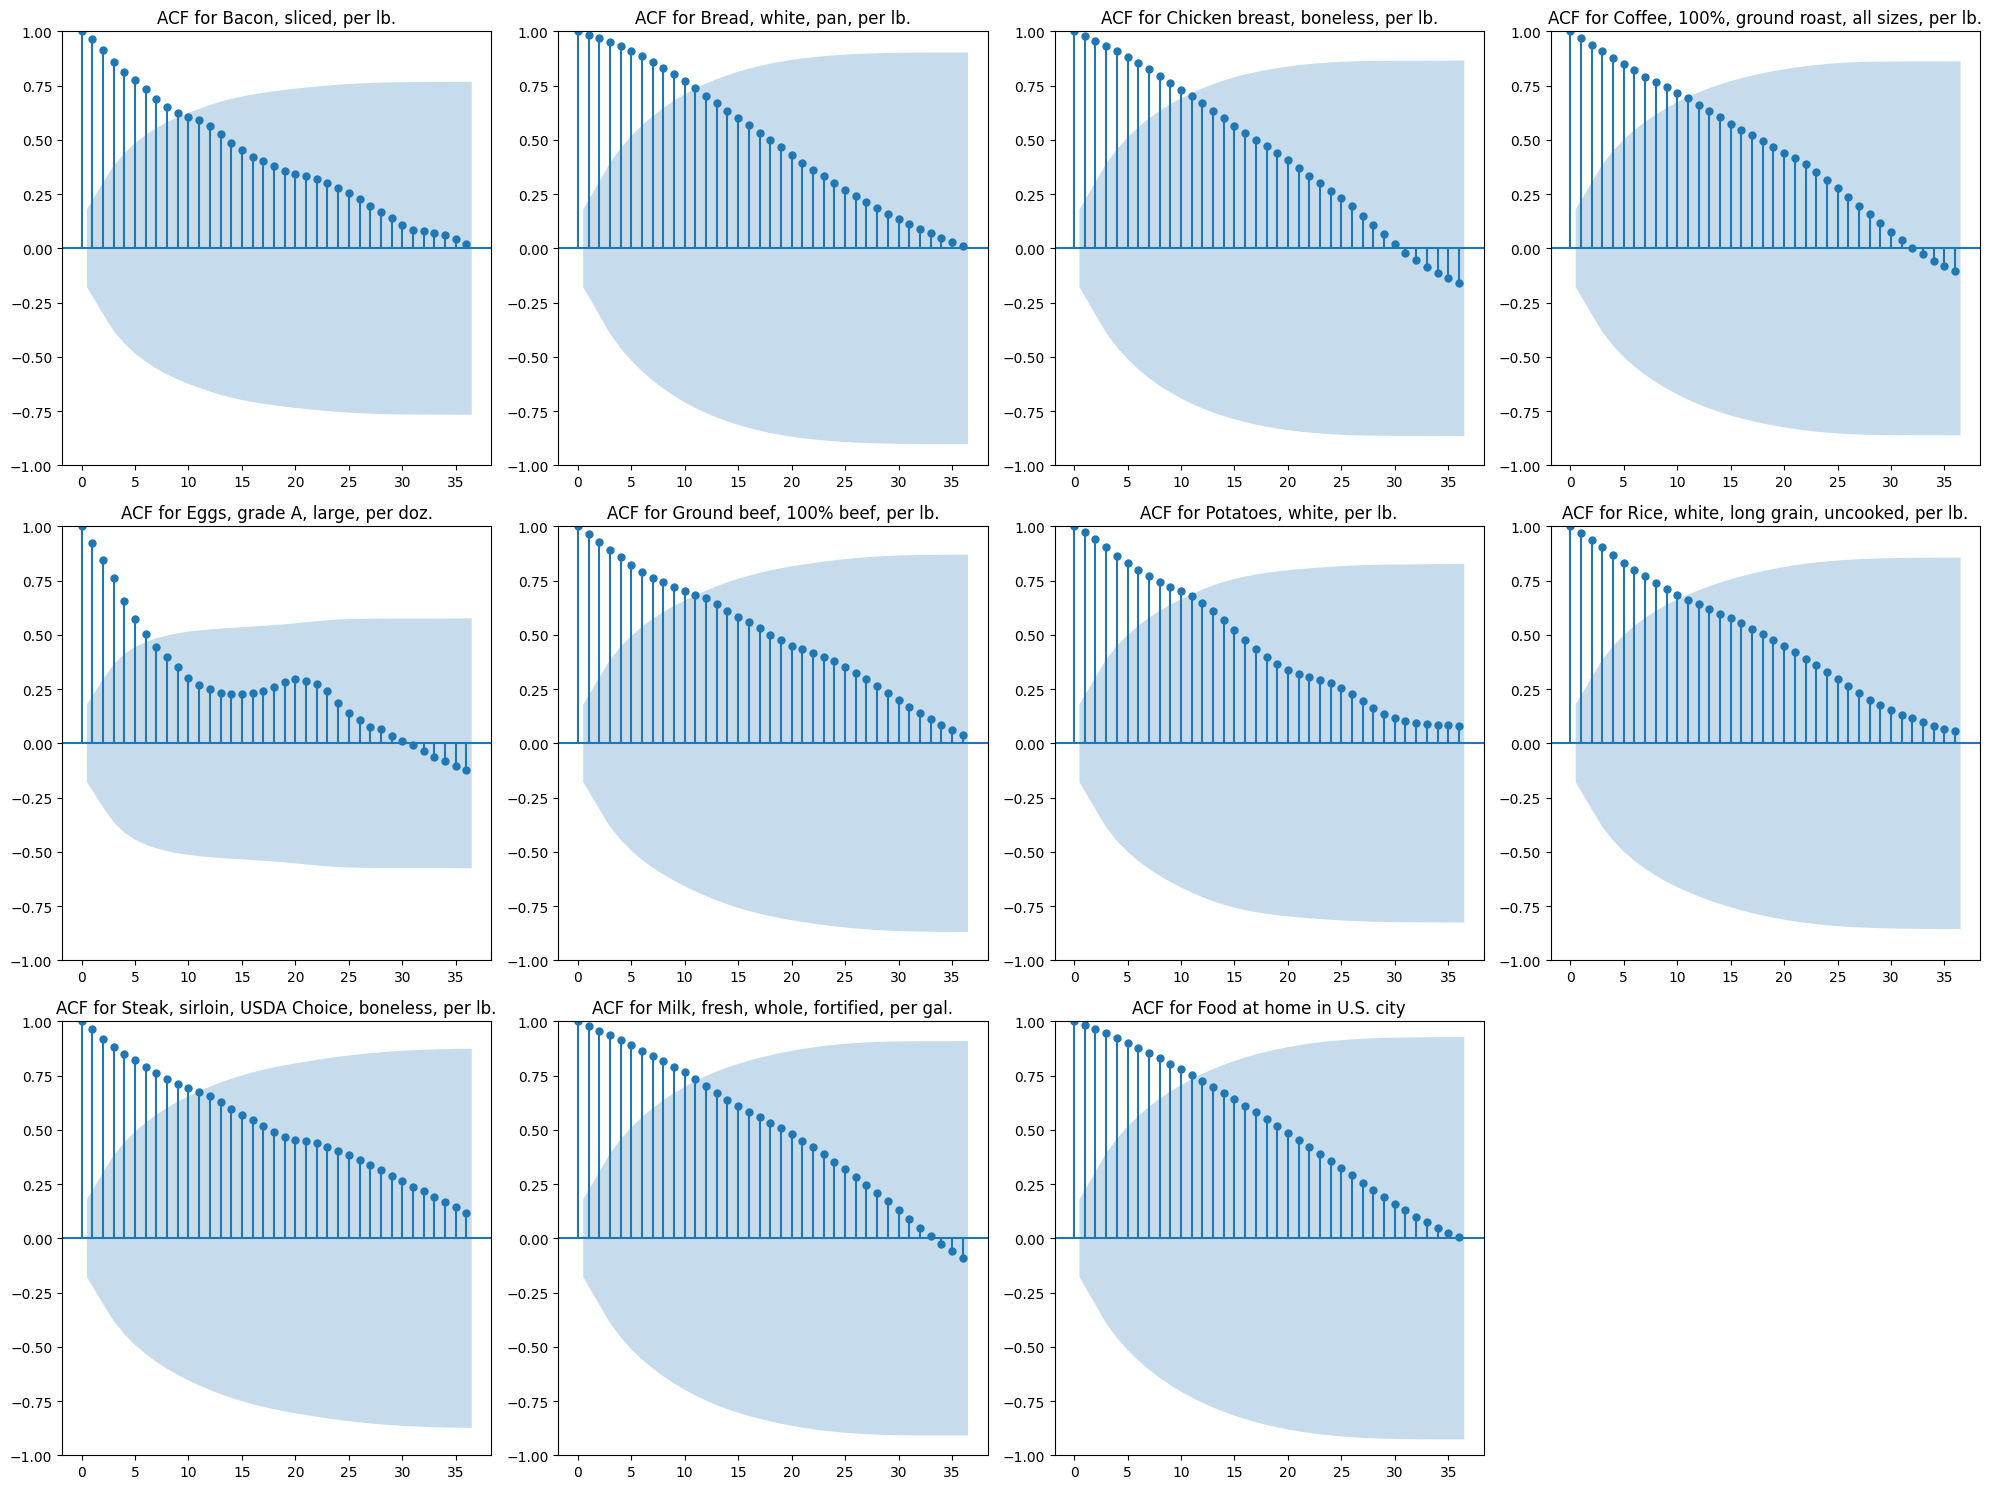

In [ ]:
# Create subplots with 3 rows and 4 columns
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through columns and plot each in a subplot
for i, series in enumerate(grocery_price_df.columns):
    plot_acf(grocery_price_df[series], lags=36, ax=axes[i])  # Look for seasonal spikes (12 months apart)
    axes[i].set_title(f"ACF for {series}")

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

After reviewing the ACF plots, there are no clear seasonal spikes at fixed intervals. The prices of food items show a gradual decay in correlation over time.



### Partial Autocorrelation Function (PACF) plot

Plot a Partial Autocorrelation Function (PACF) plot.

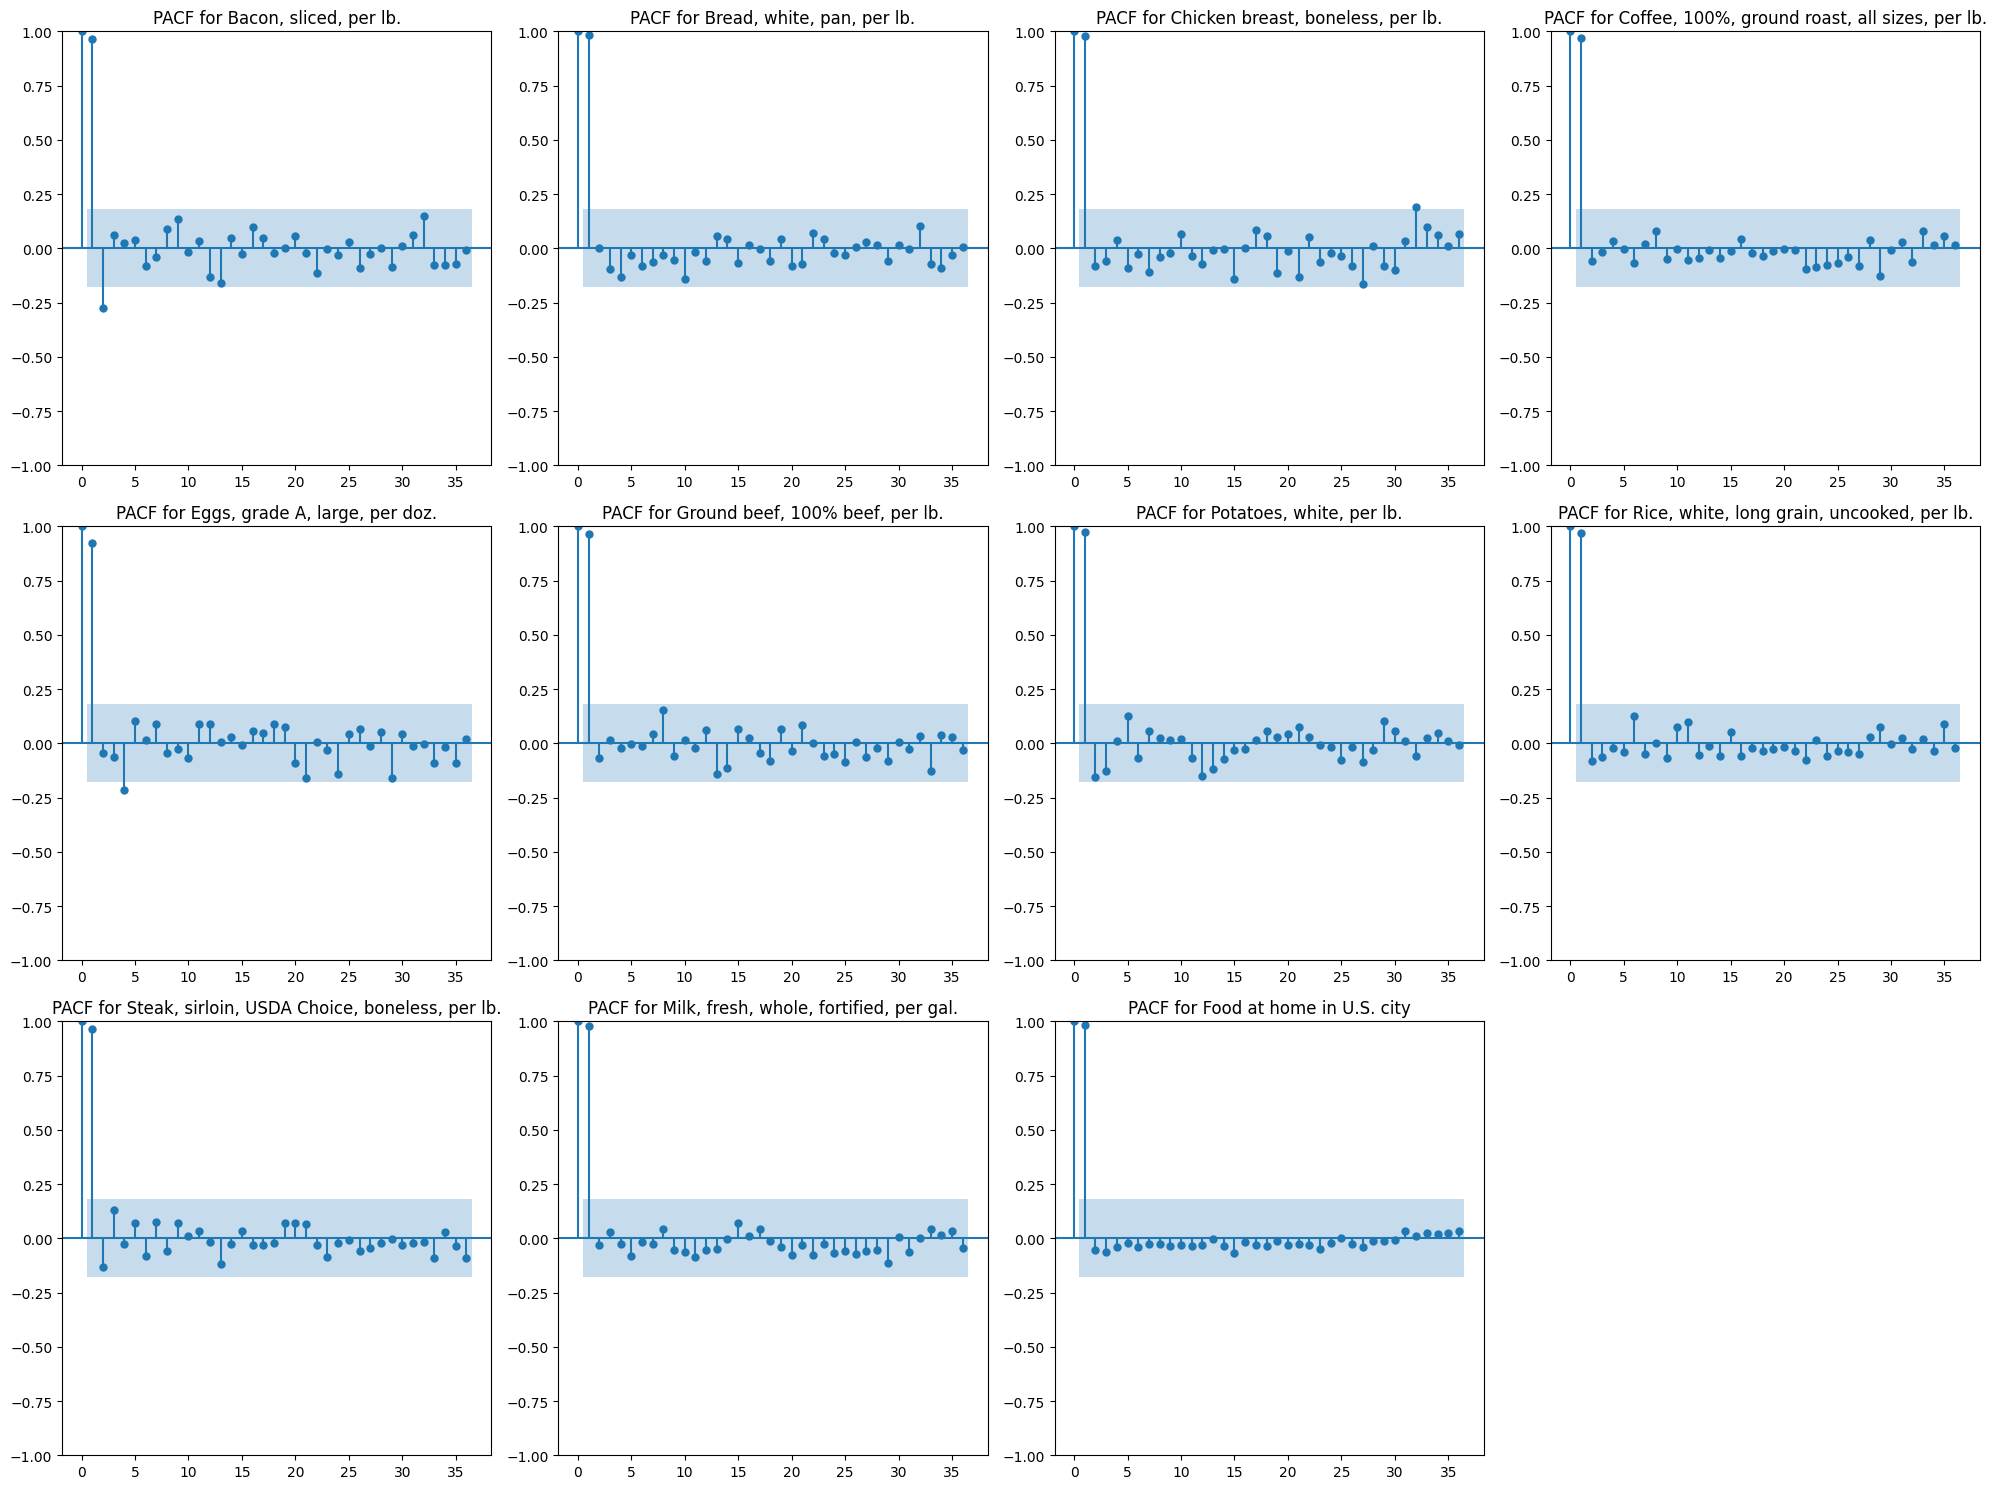

In [ ]:
# Create subplots with 3 rows and 4 columns
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through columns and plot each in a subplot
for i, series in enumerate(grocery_price_df.columns):
    plot_pacf(grocery_price_df[series], lags=36, ax=axes[i])
    axes[i].set_title(f"PACF for {series}")

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

The PACF plots have a sharp cutoff after the second lag. This suggests that the immediate past value strongly influences the next value, and a low-order autogregressive model may be suitable for time-series modeling.

With these two plots as well as the clear trends from the preliminary data visualization, we can determine that the data appears close to stationarity within the confidence interval, and with no clear seasonal spikes.

## ARIMA Forecasts and Plots

We wish to forecast the prices of items after 2020-01-01 (our designated pandemic start time). We will use an ARIMA time series model, and automate our order selection using the pmdarima auto_arima function. We will then plot the forecasts along with a 95% confidence interval.

### ARIMA Model Fitting/Forecasting

In [ ]:
# Define the forecasting test set from 2020-01-01 onwards
forecast_period = len(grocery_price_df.loc['2020-01-01':])

# Define a dictionary to hold all the forecasts
forecasts = {}

# Define a list to store ARIMA orders and AIC/BIC values
orders_aic_bic = []

# Loop through each series
for series in grocery_price_df.columns:
  # Define the training set
  train = grocery_price_df.loc[:'2019-12-01', series]
  test = grocery_price_df.loc['2020-01-01':, series]

  # Automate (p, d, q) order selection
  model_auto = auto_arima(train,
                          start_p=1, max_p=3,   # Limits AR terms (p)
                          start_q=1, max_q=3,   # Limits MA terms (q)
                          start_d=1, max_d=2,   # Differencing range
                          seasonal=False,
                          stepwise=True,
                          suppress_warnings=True)
  best_order = model_auto.order


  model = ARIMA(train, order=best_order, enforce_stationarity=False)
  model_fitted = model.fit()

  # Store orders and AIC/BIC values
  orders_aic_bic.append({
      "series": series,
      "p": best_order[0],
      "d": best_order[1],
      "q": best_order[2],
     "AIC": model_fitted.aic,
      "BIC": model_fitted.bic,
      })

  # Get forecasts for the test set
  forecast = model_fitted.get_forecast(steps=forecast_period)
  forecast_mean = forecast.predicted_mean  # Forecasted values
  conf_int = forecast.conf_int(alpha=0.05)  # 95% Confidence Interval
  forecasts[series] = {
      'forecast_mean': forecast_mean,
      'forecast_lower': conf_int.iloc[:, 0],
      'forecast_upper': conf_int.iloc[:, 1]
      }

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
#convert ARIMA orders and AIC/BIC values to a dataframe for manual comparison
orders_aic_bic_df = pd.DataFrame(orders_aic_bic)
#orders_aic_bic_df

In [ ]:
forecasts_df = pd.concat({key: pd.DataFrame(value) for key, value in forecasts.items()}, axis=1)
#forecasts_df.head()

### Model Error Metrics

In [ ]:
# Initialize lists to store error metrics for each series
mae_list = []
mse_list = []
rmse_list = []
percentage_mae_list = []
percentage_mse_list = []
percentage_rmse_list = []

# Iterate through each series and calculate error metrics
for series in grocery_price_df.columns:
    actual = grocery_price_df.loc['2020-01-01':, series]
    forecast = forecasts[series]["forecast_mean"]

    # Calculate MAE, MSE, RMSE metrics
    mae = mean_absolute_error(actual, forecast)
    mse = mean_squared_error(actual, forecast)
    rmse = np.sqrt(mse)

    # Calculate the percentage metrics
    percentage_mae = (mae / np.mean(actual)) * 100
    percentage_mse = (mse / np.mean(actual)) * 100
    percentage_rmse = (rmse / np.mean(actual)) * 100

    # Append all metrics to the lists
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    percentage_mae_list.append(percentage_mae)
    percentage_mse_list.append(percentage_mse)
    percentage_rmse_list.append(percentage_rmse)

    print(f'{series} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}')
    print(f'{series} - Percentage MAE: {percentage_mae:.2f}%, Percentage MSE: {percentage_mse:.2f}%, Percentage RMSE: {percentage_rmse:.2f}%\n')

# Calculate and print overall metrics
overall_mae = np.mean(mae_list)
overall_mse = np.mean(mse_list)
overall_rmse = np.mean(rmse_list)

print(f'Overall - MAE: {overall_mae:.2f}, MSE: {overall_mse:.2f}, RMSE: {overall_rmse:.2f}')
print(f'Overall - Percentage MAE: {np.mean(percentage_mae_list):.2f}%, Percentage MSE: {np.mean(percentage_mse_list):.2f}%, Percentage RMSE: {np.mean(percentage_rmse_list):.2f}%')

Bacon, sliced, per lb. - MAE: 1.07, MSE: 1.51, RMSE: 1.23
Bacon, sliced, per lb. - Percentage MAE: 16.21%, Percentage MSE: 22.84%, Percentage RMSE: 18.62%

Bread, white, pan, per lb. - MAE: 0.36, MSE: 0.18, RMSE: 0.42
Bread, white, pan, per lb. - Percentage MAE: 20.83%, Percentage MSE: 10.35%, Percentage RMSE: 24.53%

Chicken breast, boneless, per lb. - MAE: 0.82, MSE: 0.89, RMSE: 0.94
Chicken breast, boneless, per lb. - Percentage MAE: 21.23%, Percentage MSE: 23.11%, Percentage RMSE: 24.49%

Coffee, 100%, ground roast, all sizes, per lb. - MAE: 1.45, MSE: 2.77, RMSE: 1.66
Coffee, 100%, ground roast, all sizes, per lb. - Percentage MAE: 26.33%, Percentage MSE: 50.33%, Percentage RMSE: 30.25%

Eggs, grade A, large, per doz. - MAE: 0.90, MSE: 1.51, RMSE: 1.23
Eggs, grade A, large, per doz. - Percentage MAE: 37.49%, Percentage MSE: 62.88%, Percentage RMSE: 51.18%

Ground beef, 100% beef, per lb. - MAE: 0.64, MSE: 0.57, RMSE: 0.75
Ground beef, 100% beef, per lb. - Percentage MAE: 13.61%, P

### Error Metrics Interpretation

In general, an MAE of 4.49 (20.01%) suggests a moderate error across all items. An MSE of 206.56 (96.14%) is a very high error that suggests models have large outliers that are affecting its performance. The RMSE value 5.20 (23.92%) suggests that the discrepancies in models could be inflated by larger individual errors.


---


Individual breakdowns are as the following:

* The errors from the Bacon model are in the lower-moderate range, indicating that the forecasted prices are slightly reliable.

* The RMSE value of 0.42 (24.53%) in the Bread model suggests that some outliers are affecting the performance of the model, though the forecast has a relatively good fit.

* There are moderate error percentages for the Chicken Breast model, meaning that the prices of chicken could be improved, but are still somewhat reliable depending on the context.

* All error metrics for Coffee lead to large inaccuracies in forecasting prices, meaning the model struggled in accurately predicting Coffee prices.

* The error metrics for Eggs are larger than the previous series (Coffee), also suggesting inaccuracies in prices. This could be attributed to other external factors such as the Avian Flu.

* The low-to-moderate range of errors in the Ground Beef forecasted prices suggests a good fit to the model.

* The MSE value of 0.02 (2.62%) in the Potatoes model suggest very small errors, with a moderate discrepancy from individual errors. This model is a good fit.

* Similar to the chicken breast model, the Rice predictions are somewhat reliable in accuracy. The MSE value of 0.05 (5.08%) indicates that the predicted values are really close to the actual values, though there is a moderate discrepancy due to individual errors.

* Poor performance is indicated in the Steak model due to large prediction errors that inflate the MSE.

* The forecasts in Milk prices are relatively accurate.

* The MSE 2258.59 (802.60%) for Food at Home is past the point of consideration. This category cannot forecast food prices accurately due to this large error. Other factors may have caused this model to fit poorly.


### Model Plotting

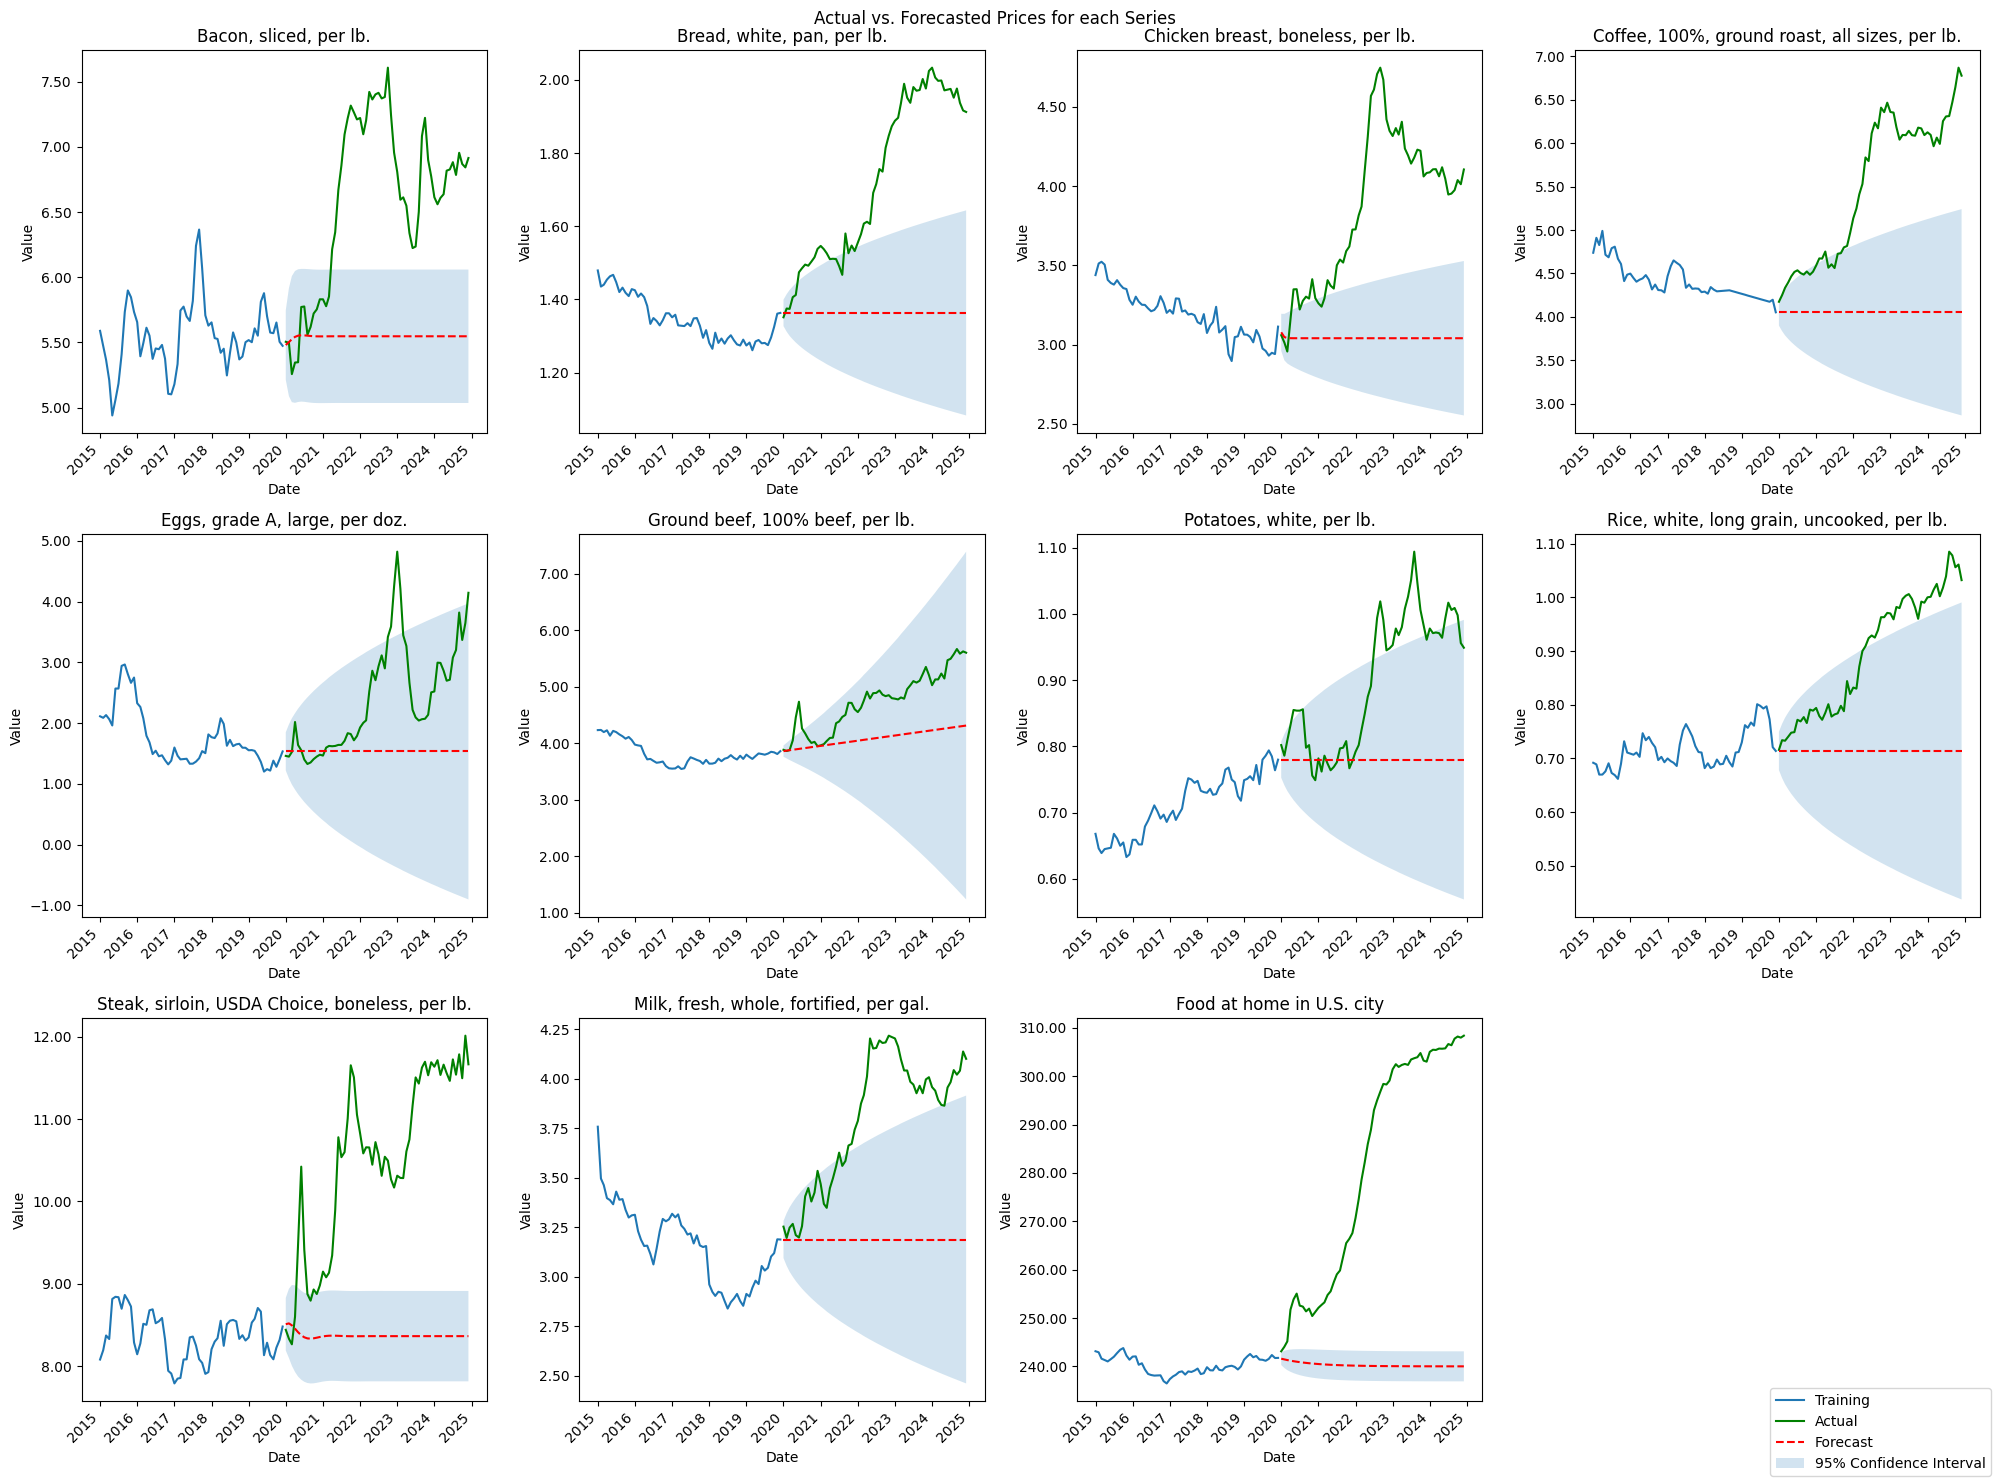

In [ ]:
# Create subplots with 3 rows and 4 columns
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through columns (excluding 'Date' as it is the index) and plot each in a subplot
for i, series in enumerate(grocery_price_df.columns):
    axes[i].plot(grocery_price_df.loc['2015-01-01':'2019-12-01', series], label=f'Training')
    axes[i].plot(grocery_price_df.loc['2020-01-01':, series], label=f'Actual', color='green')
    forecast_mean = forecasts[series]["forecast_mean"]
    axes[i].plot(forecast_mean, label=f'Forecast',linestyle='dashed', color='red')

    # Plot confidence intervals
    axes[i].fill_between(
        forecast_mean.index,
        forecasts[series]["forecast_lower"],
        forecasts[series]["forecast_upper"],
        alpha=0.2,
        label="95% Confidence Interval"
    )

    axes[i].set_title(series)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value')
    # Format y axis ticks to 2 decimal places
    axes[i].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.2f}'))
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')


plt.suptitle('Actual vs. Forecasted Prices for each Series')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right")

# Hide the last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Model Interpretation

Each series was fitted into an ARIMA time series model based on historical data from 2015-2019. Values for each food product were forecasted on the basis of predicting prices reflecting pre-COVID-19 trends. This allowed the model to focus on "normal" price trends.

Certain food items, such as Ground Beef, Potatoes, and Rice, presented with low-to-moderate Mean Absolute Errors (MAE), Mean Squared Errors (MSE), and Root Mean Squared Errors (RSME). Along with these error metrics, the actual prices of these items from 2020-2024 mostly stayed in, or around, the 95% confidence interval of predicted prices. This means that the ARIMA model was fitted decently well within these items. This could be attributed to more stable supply chains or predictability in consumer demand, leading to price stability.

On the other hand, items such as Sirloin Steak, Eggs, and Coffee were fitted more poorly to the ARIMA model as they have high forecast errors, along with prices that deviate greatly from the confidence intervals our model created. Our consumer price index values for all groceries in our model are highly inaccurate compared to the actual values. These large errors may be attributed to issues that arose from the pandemic, including supply and demand, labor and production disruptions, supply chain issues, etc. 'Food at Home' specifically represents the CPI of groceries, and indicates that a large shift in grocery prices occurred beginning in 2020.

Although the ARIMA model gave us a good indication of COVID-19 influences, a more in-depth analysis into these exogenous variables is needed to determine a causal effect of the pandemic on grocery prices.

# Price Correlations

We wish to understand how prices of food items are correlated with each other, meaning how similar their price beheviors are. We are able to several methods to showcase the similarity in price movements.

## Correlation Matrix

In [ ]:
# Rename labels for easier interpretation
item_labels = [label.split(',')[0] for label in grocery_price_df.columns]

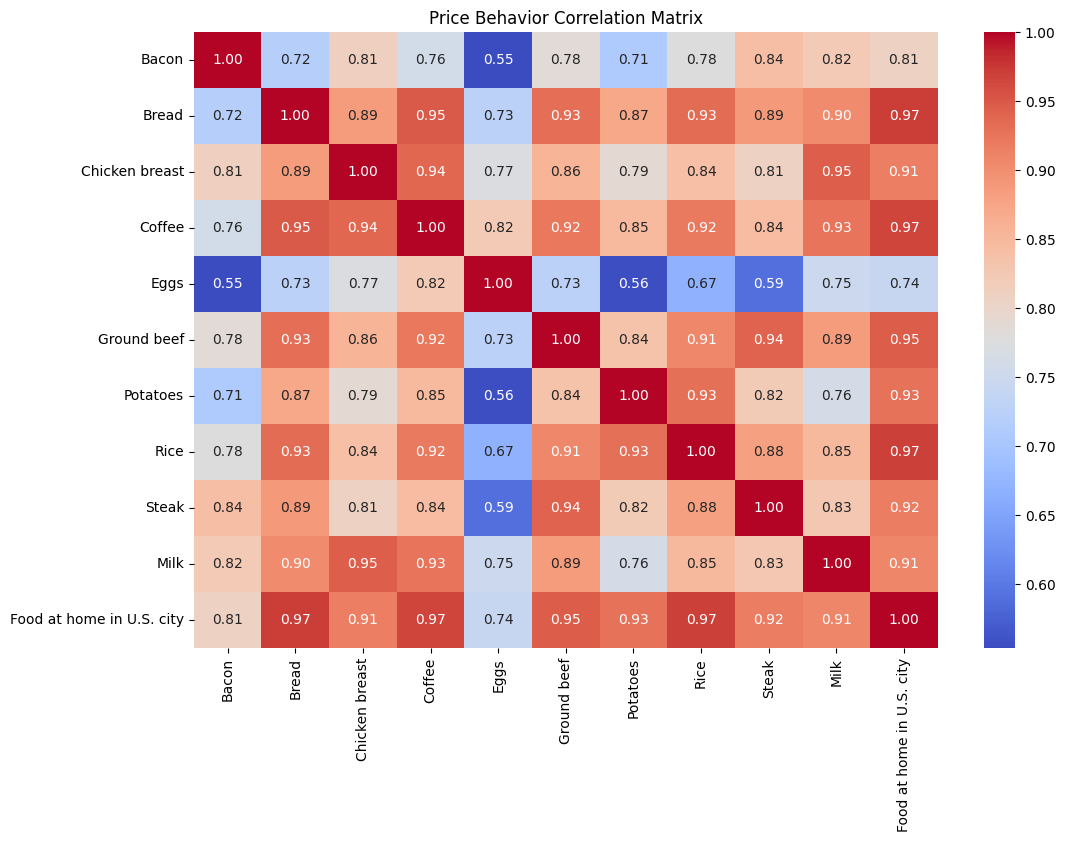

In [ ]:
# Create a correlation matrix
correlation_matrix = grocery_price_df.corr()

# Plot the matrix as a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", xticklabels = item_labels, yticklabels=item_labels)
plt.title('Price Behavior Correlation Matrix')
plt.show()


The correlation matrix suggests very strong correlations (>= 0.90) with the following food series:
*   Bread & Food at Home
*   Chicken Breast & Food at Home
*   Coffee & Food at Home
*   Ground Beef & Food at Home
*   Potatoes & Food at Home
*   Rice & Food at Home
*   Steak & Food at Home
*   Milk & Food at Home
*   Bread & Milk
*   Chicken Breast & Milk
*   Coffee & Milk
*   Ground Beef & Steak
*   Bread & Rice
*   Ground Beef & Rice
*   Rice & Potatoes
*   Bread & Ground Beef
*   Coffee & Ground Beef
*   Bread & Coffee
*   Chicken Breast & Coffee
*   Rice & Coffee

The correlation matrix also suggests weak or uncorrelated (< 0.70) price behaviors with the following:
*   Eggs & Bacon
*   Eggs & Potatoes
*   Eggs & Rice
*   Eggs & Steak


### Interpretation of Correlation Matrix

Foods that are highly correlated with the 'Food at Home' series suggest that these items are staples in American households and are subject to price fluctuations based on market trends. Other strong correlations may be influenced by consumer demand shifts based on the economy. Specific correlations such as Ground Beef & Steak, Bread & Rice, and Rice & Potatoes could be attributed to the food groups they are a part of, subject to exogenous variables such as labor costs and weather conditions for agricultural trends.

Eggs are the basis of the weakly correlated price behaviors, and could be attributed to the avian flu and feed costs due to rising grain prices. Eggs come from entirely different sources than their pairs, and have a completely separate supply chain and forms of consumption.

## Clustering

### Dendrogram

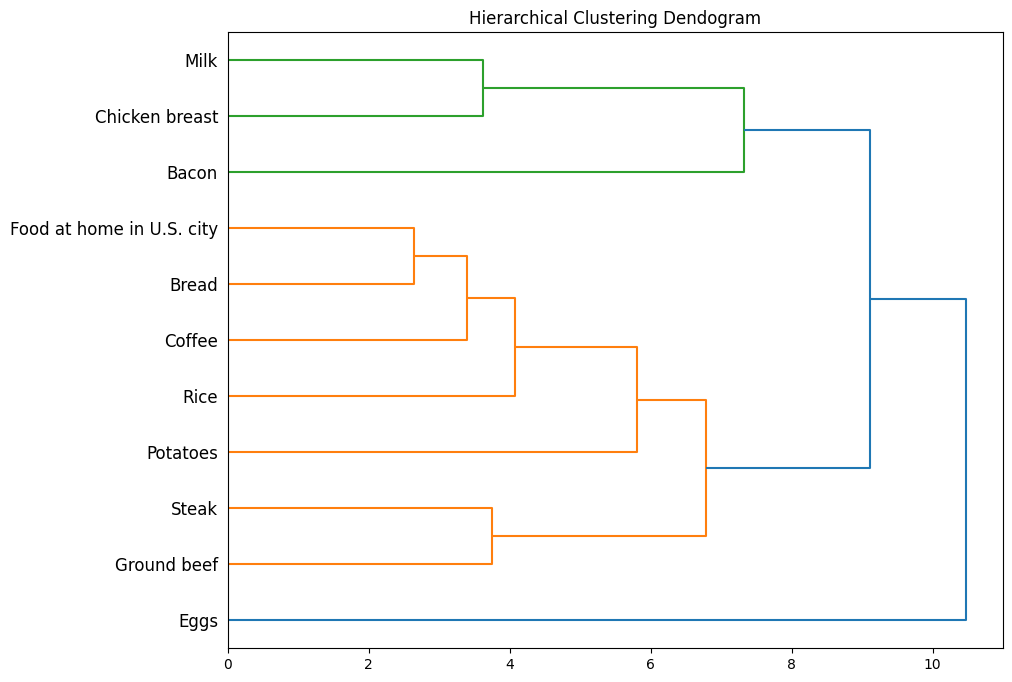

In [ ]:
# Scale the data to a uniform scale
scaled_data = StandardScaler().fit_transform(grocery_price_df)

# Transpose the scaled data to cluster based on features
scaled_data = scaled_data.T

linkage_data = linkage(scaled_data, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 8))
dendrogram(linkage_data, labels=item_labels, orientation='right')
plt.title('Hierarchical Clustering Dendogram')
plt.show()

The dendrogram seems to suggest five major clusters that best fit our data. From the dendrogram, we notice that there is a strong similarity in prices between Chicken Breast and Milk, linking poultry and dairy together. Similarly, Ground Beef and Steak are clustered as beef prices. Food at Home, Bread, Coffee, Rice, and Potatoes are all linked to similar price behaviors. The price patterns of Bacon are separated, and the prices of Eggs are completely independent from the other prices.

### Principal Component Analysis (PCA)

In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

# Define a function to plot PCA with adjustable clusters
def plot_pca_clusters(n_clusters):
  kmeans = KMeans(n_clusters=n_clusters, random_state=42)
  pca_df['Cluster'] = kmeans.fit_predict(principal_components)

  # Plot PCA
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], marker='o', s=100)

  # Add titles/axes
  plt.title(f'PCA of Price Behaviors in {n_clusters} clusters')
  plt.xlabel('Principal Component 1')
  plt.ylabel('Principal Component 2')

  # Label each item
  for i, label in enumerate(item_labels):
    plt.text(pca_df['PC1'][i], pca_df['PC2'][i], label, fontsize=8)

  # Create legend and show plot
  plt.legend(*scatter.legend_elements(), loc='upper right', title='Clusters')
  plt.show()

# Create an interactive slider for number of clusters
interact(plot_pca_clusters, n_clusters=IntSlider(min=2, max=10, step=1, value=5))

interactive(children=(IntSlider(value=5, description='n_clusters', max=10, min=2), Output()), _dom_classes=('w…

<function __main__.plot_pca_clusters(n_clusters)>

Similarly to the dendrogram, our food items are best clustered with five clusters. Using Principal Component Analysis (PCA), our data suggests Eggs, Steak, and Bacon have isolated price behaviors. Milk and Chicken Breast are grouped as poultry and dairy. Potatoes, Rice, Bread, Coffee, Ground Beef, and our Food at Home index are all grouped together in one cluster, suggesting that these are staple items.

# Grocery Affordability Analysis

## Census Data Parsing

Parse the .xlsx dataset provided by the U.S. Census on estimated income data for different races. For simplicity, we assume that the average income for a household is represented as the estimated median income in dollars.

In [ ]:
xls = pd.ExcelFile('/content/drive/MyDrive/Data Mining/census data/census_cpi.xlsx')
df = xls.parse('tableA2', header=None)

# Save each row of data as a dictionary
extracted_data = []
# Holds the current race
current_race = None

# Loop through each row of the dataset
for index, row in df.iterrows():
  first_column_cell = str(row[0]).strip()

  # If the cell in the first column matches the format of a race label, update the race
  if first_column_cell.isupper() and not any(char.isdigit() for char in first_column_cell):
    current_race = first_column_cell

  # If the cell starts with a year and there is a value in the median income column
  elif first_column_cell[:4].isdigit() and pd.notna(row[12]):
    try:
      # Extract the year from the first 4 characters
      year = int(first_column_cell[:4])
      # Extract the estimated income
      income = int(row[12])
      # Save the row to a dictionary
      extracted_data.append({'Year': year, 'Race': current_race, 'Median Income (dollars)': income})
    except:
      continue

# Transform the data into a dataframe, only keeping years 2015-2023, pivoted by year
census_df = (pd.DataFrame(extracted_data)
              .query('Year >= 2015')
              .drop_duplicates(subset=['Year', 'Race'], keep='first')
              .pivot(index='Year', columns='Race', values='Median Income (dollars)')
              .sort_index(ascending=False)
             )

In [ ]:
census_df

Race,ALL RACES,AMERICAN INDIAN AND ALASKA NATIVE ALONE,AMERICAN INDIAN AND ALASKA NATIVE ALONE OR IN COMBINATION,ASIAN ALONE,ASIAN ALONE OR IN COMBINATION,BLACK ALONE,BLACK ALONE OR IN COMBINATION,HISPANIC (ANY RACE),TWO OR MORE RACES,WHITE ALONE,"WHITE ALONE, NOT HISPANIC"
Year,,,,,,,,,,,
2023,80610,57270,61060,112800,112200,56490,56880,65540,68860,84630,89050
2022,77540,54910,60360,113100,113700,54960,55620,65300,72230,80320,84280
2021,79260,57220,57430,113600,113200,54080,54660,64930,71650,83160,87340
2020,79560,57170,63330,111300,111100,53840,54700,64840,81340,83800,88200
2019,81210,58380,60290,116000,114800,53710,54460,66330,72770,85350,89900
2018,75790,52510,56700,104600,104100,49620,50010,61720,66660,80300,84740
2017,74810,47000,54550,99600,99130,48170,48930,61390,65230,79340,83450
2016,73520,51900,52980,101400,100600,49170,49890,59370,64060,77030,80990
2015,71000,50160,53730,96940,96430,46350,46750,56720,62320,75510,79080


## Grocery Consumer Index vs. Race

### Affordability Index

Calculate the affordability index metric for each race by year. The Affordability Index is calculated as the Food Price Index divided by the Median Household Income, multiplied by 100. A higher affordability index value represents more burden placed on an income.

In [ ]:
# Use the Food at Home consumer index and calculate the annual average
annual_prices = grocery_price_df['Food at home in U.S. city'].resample('Y').mean().reset_index()
annual_prices.columns = ['Year', 'Avg_Grocery_Index']
annual_prices['Year'] = annual_prices['Year'].dt.year

# Merge annual average of grocery index with race incomes
grocery_income_df = pd.merge(annual_prices, census_df, on='Year', how='inner')
grocery_income_df

,Year,Avg_Grocery_Index,ALL RACES,AMERICAN INDIAN AND ALASKA NATIVE ALONE,AMERICAN INDIAN AND ALASKA NATIVE ALONE OR IN COMBINATION,ASIAN ALONE,ASIAN ALONE OR IN COMBINATION,BLACK ALONE,BLACK ALONE OR IN COMBINATION,HISPANIC (ANY RACE),TWO OR MORE RACES,WHITE ALONE,"WHITE ALONE, NOT HISPANIC"
0,2015,242.250000,71000,50160,53730,96940,96430,46350,46750,56720,62320,75510,79080
1,2016,239.065083,73520,51900,52980,101400,100600,49170,49890,59370,64060,77030,80990
2,2017,238.589083,74810,47000,54550,99600,99130,48170,48930,61390,65230,79340,83450
3,2018,239.661083,75790,52510,56700,104600,104100,49620,50010,61720,66660,80300,84740
4,2019,241.774500,81210,58380,60290,116000,114800,53710,54460,66330,72770,85350,89900
5,2020,250.232833,79560,57170,63330,111300,111100,53840,54700,64840,81340,83800,88200
6,2021,258.891750,79260,57220,57430,113600,113200,54080,54660,64930,71650,83160,87340
7,2022,288.451083,77540,54910,60360,113100,113700,54960,55620,65300,72230,80320,84280
8,2023,302.928917,80610,57270,61060,112800,112200,56490,56880,65540,68860,84630,89050


In [ ]:
# Create a dataframe to calculate affordability index
affordability_df = pd.DataFrame()

# Calculate affordability index for each race as the ratio of price index to income, multiplied by 100
for race in grocery_income_df.columns[2:]:
  affordability_df['Year'] = grocery_income_df['Year']
  affordability_df['Avg_Grocery_Index'] = grocery_income_df['Avg_Grocery_Index']
  affordability_df[f'{race}'] = grocery_income_df['Avg_Grocery_Index'] / grocery_income_df[race] * 100

affordability_df

,Year,Avg_Grocery_Index,ALL RACES,AMERICAN INDIAN AND ALASKA NATIVE ALONE,AMERICAN INDIAN AND ALASKA NATIVE ALONE OR IN COMBINATION,ASIAN ALONE,ASIAN ALONE OR IN COMBINATION,BLACK ALONE,BLACK ALONE OR IN COMBINATION,HISPANIC (ANY RACE),TWO OR MORE RACES,WHITE ALONE,"WHITE ALONE, NOT HISPANIC"
0,2015,242.250000,0.341197,0.482955,0.450865,0.249897,0.251219,0.522654,0.518182,0.427098,0.388720,0.320818,0.306335
1,2016,239.065083,0.325170,0.460626,0.451236,0.235764,0.237639,0.486201,0.479184,0.402670,0.373189,0.310353,0.295179
2,2017,238.589083,0.318927,0.507636,0.437377,0.239547,0.240683,0.495306,0.487613,0.388645,0.365766,0.300717,0.285907
3,2018,239.661083,0.316217,0.456410,0.422683,0.229121,0.230222,0.482993,0.479226,0.388304,0.359528,0.298457,0.282819
4,2019,241.774500,0.297715,0.414139,0.401019,0.208426,0.210605,0.450148,0.443949,0.364502,0.332245,0.283274,0.268937
5,2020,250.232833,0.314521,0.437700,0.395125,0.224827,0.225232,0.464771,0.457464,0.385924,0.307638,0.298607,0.283711
6,2021,258.891750,0.326636,0.452450,0.450795,0.227898,0.228703,0.478720,0.473640,0.398724,0.361328,0.311318,0.296418
7,2022,288.451083,0.372003,0.525316,0.477884,0.255041,0.253695,0.524838,0.518610,0.441732,0.399351,0.359127,0.342253
8,2023,302.928917,0.375796,0.528949,0.496117,0.268554,0.269990,0.536252,0.532575,0.462205,0.439920,0.357945,0.340178


### Grocery Affordability Plot

Plot the Affordability Index metric by race.

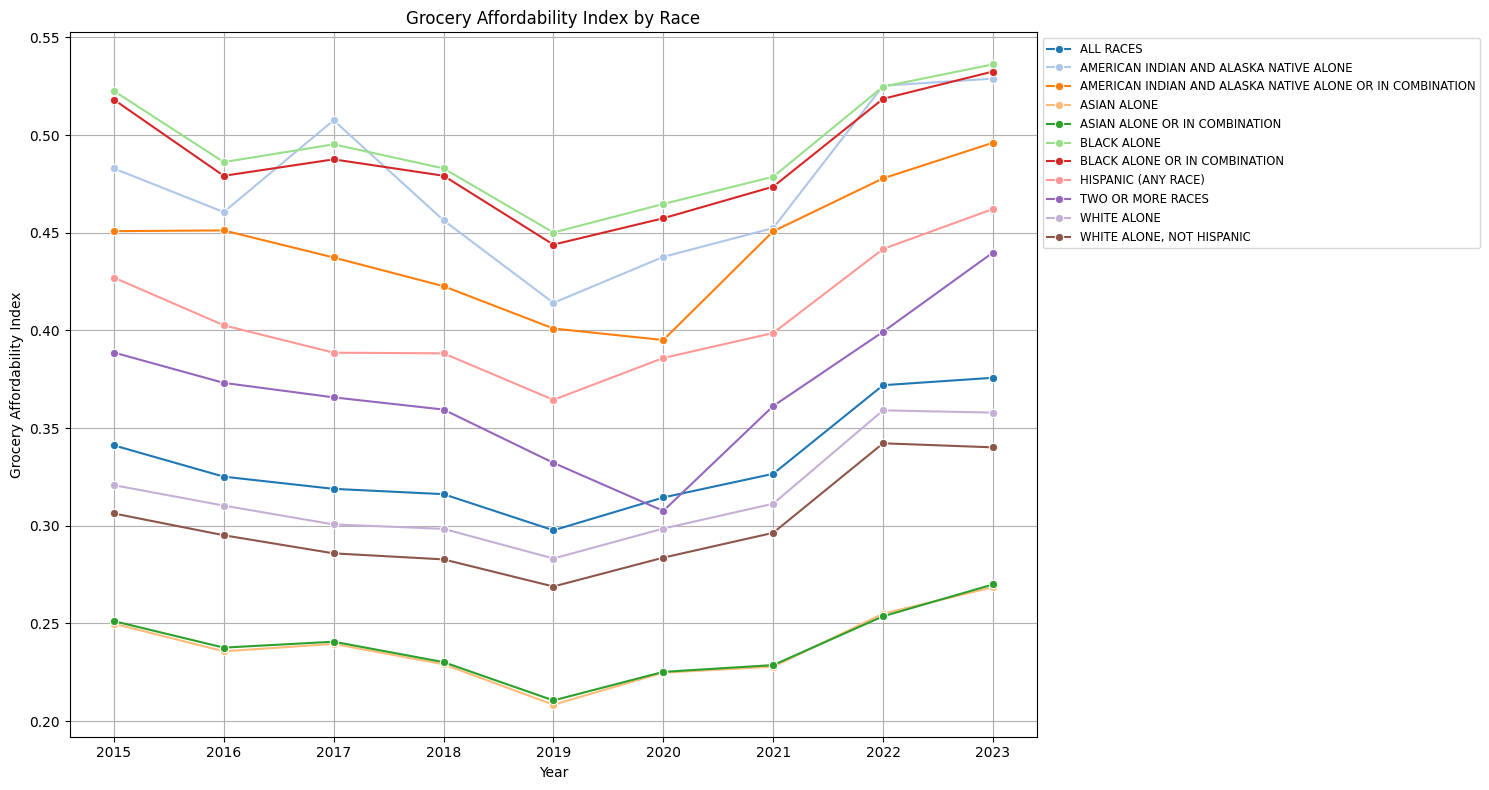

In [ ]:
# Define a color palette for plotting
palette = sns.color_palette("tab20", len(affordability_df.columns[2:]))

plt.figure(figsize=(15, 8))

# Plot the affordability index for each race
for index, race in enumerate(affordability_df.columns[2:]):
  sns.lineplot(x=affordability_df['Year'], y=affordability_df[race], label=race, marker='o', color=palette[index])

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Grocery Affordability Index')
plt.title('Grocery Affordability Index by Race')
plt.legend(loc='best', bbox_to_anchor=(1, 1), fontsize='small')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

### Affordability Index Interpretation

By analyzing the affordability index metric against grocery prices from 2015-2023, we notice a relatively decreasing trend from 2015-2019, followed by an upwards trend from 2019-2023. This indicates that grocery prices were becoming more affordable to the U.S. household until 2019, followed by worsening affordability onwards. This suggests that the COVID-19 Pandemic had economic impacts on all households.

For all racial groups, groceries are becoming a larger portion of household expenses. Black and American Indian and Alaskan Native populations consistently experienced the most financial burden when purchasing groceries. Both these groups had an approximate 2x more burden than the Asian populations. Asians and White populations experience the least burden when buying groceries.

## Relative Grocery Affordability of U.S. Households

### Relative Affordability

Calculate the relative affordability of each race compared to the average U.S. household (ALL RACES). This is the ratio of the affordability index of each race by the benchmark.

In [ ]:
# Use 'ALL RACES' as a benchmark column - used to represent the average of all U.S. Households
benchmark_col = 'ALL RACES'

# Create a dataframe to store affordability ratios
relative_affordability_df = pd.DataFrame()
# Calculate the relative affordability ratio between each race and the benchmark
for race in affordability_df.columns[3:]:
  relative_affordability_df['Year'] = affordability_df['Year']
  relative_affordability_df[f'{race}'] = affordability_df[race] / affordability_df[benchmark_col]

relative_affordability_df

,Year,AMERICAN INDIAN AND ALASKA NATIVE ALONE,AMERICAN INDIAN AND ALASKA NATIVE ALONE OR IN COMBINATION,ASIAN ALONE,ASIAN ALONE OR IN COMBINATION,BLACK ALONE,BLACK ALONE OR IN COMBINATION,HISPANIC (ANY RACE),TWO OR MORE RACES,WHITE ALONE,"WHITE ALONE, NOT HISPANIC"
0,2015,1.415470,1.321422,0.732412,0.736285,1.531823,1.518717,1.251763,1.139281,0.940273,0.897825
1,2016,1.416570,1.387693,0.725049,0.730815,1.495221,1.473642,1.238336,1.147674,0.954433,0.907766
2,2017,1.591702,1.371402,0.751104,0.754666,1.553041,1.528919,1.218602,1.146865,0.942904,0.896465
3,2018,1.443344,1.336684,0.724570,0.728050,1.527408,1.515497,1.227965,1.136964,0.943836,0.894383
4,2019,1.391059,1.346990,0.700086,0.707404,1.512009,1.491186,1.224333,1.115982,0.951494,0.903337
5,2020,1.391639,1.256277,0.714825,0.716112,1.477712,1.454479,1.227020,0.978117,0.949403,0.902041
6,2021,1.385180,1.380115,0.697711,0.700177,1.465607,1.450055,1.220699,1.106211,0.953102,0.907488
7,2022,1.412129,1.284626,0.685588,0.681970,1.410844,1.394103,1.187443,1.073515,0.965388,0.920028
8,2023,1.407543,1.320177,0.714628,0.718449,1.426978,1.417194,1.229936,1.170636,0.952499,0.905222


### Relative Affordability Plot

Plot the relative affordability ratios of each race compared to the benchmark.

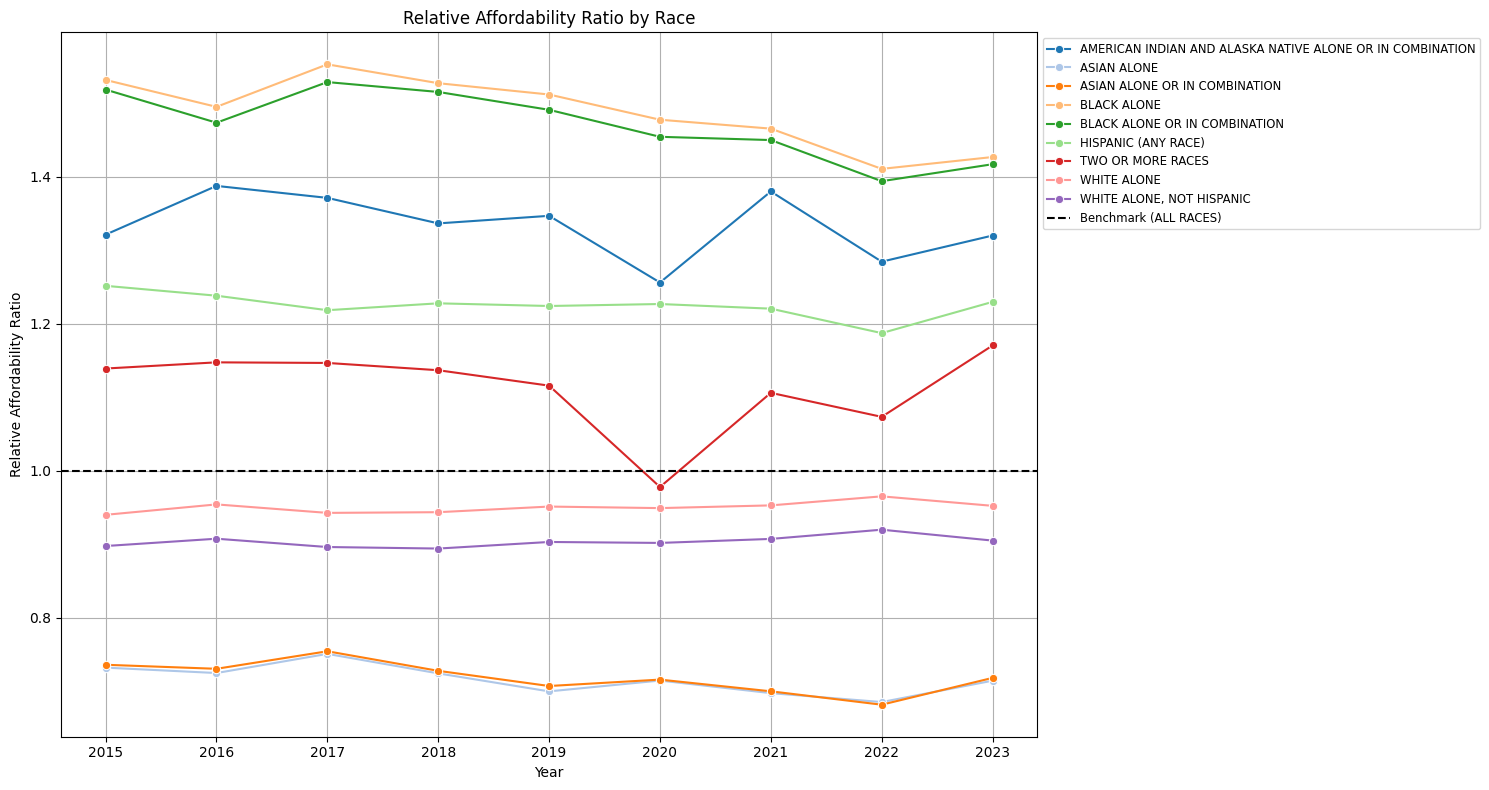

In [ ]:
plt.figure(figsize=(15, 8))

# Plot the relative affordability for each race for the benchmark 'ALL RACES'
for index, race in enumerate(relative_affordability_df.columns[2:]):
  sns.lineplot(x=relative_affordability_df['Year'], y=relative_affordability_df[race], label=race, marker='o', color=palette[index])

# Add labels and title
plt.axhline(1, color='black', linestyle='--', label='Benchmark (ALL RACES)') # Labels the benchmark ratio as 1.0
plt.xlabel('Year')
plt.ylabel('Relative Affordability Ratio')
plt.title('Relative Affordability Ratio by Race')
plt.legend(loc='best', bbox_to_anchor=(1, 1), fontsize='small')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

### Relative Affordability Interpretation

The benchmark dashed line at 1.0 represents the burden of the average U.S. household. The Black Alone and/or in Combination groups are between 1.4 and 1.6, meaning that these groups face 40-60% more financial burden with groceries than the average household. Hispanic and American Indian and Alaskan Native households face between 20-40% more burden. Asian and White populations consistently face lesser burdens than the average household, which showcases less pressure on their incomes.